# CausalML API: Quick Start

This notebook provides a runnable walkthrough of the `CausalNavigator` API.
Each section pairs the API documentation with a live code cell so you can
test every method end-to-end.

The `CausalML` module is a high-level wrapper around the `causalml` library
designed to simplify causal inference workflows for observational studies. It
includes the `CausalNavigator` class for heterogeneous treatment effect
estimation, diagnostic methods for assumption validation, and helper
functions for data preprocessing and visualisation.

## Architecture

While `causalml` provides powerful meta-learners (S/T/X-Learners), the
native API requires significant boilerplate for data preprocessing,
assumption checking, and visualisation. `CausalNavigator` standardises that
workflow into a single class.

The core pipeline has three layers:

1. **Diagnostic Layer**: Verifies causal assumptions (specifically Common
   Support) before estimation
2. **Estimation Layer**: Wraps `causalml.inference.meta` classes
   (`BaseXRegressor`, etc.) and injects XGBoost as the standard base learner
3. **Interpretation Layer**: Provides built-in methods to visualise
   heterogeneity, abstracting away `matplotlib` complexity

## Setup

In [1]:
%load_ext autoreload
%autoreload 2


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import logging
import utils

import warnings
warnings.filterwarnings("ignore")

_LOG = logging.getLogger(__name__)
utils.init_logger(_LOG)

INFO  > cmd='/opt/venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-a17e709d-653a-4e17-8cac-c16690a9ba10.json'


/opt/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os

# TODO(gp): Use import X.
from utils import (
    CausalNavigator,
    download_cdc_data_if_needed,
    load_cdc_data,
    preprocess_for_causal,
)

### Load data set.

In [4]:
# Download and load the dataset.
filename = "diabetes_binary_health_indicators_BRFSS2015.csv"
data_path = os.path.join("data", "unprocessed", filename)
download_cdc_data_if_needed(data_path)
df_raw = load_cdc_data(data_path)

Dataset already present at: data/unprocessed/diabetes_binary_health_indicators_BRFSS2015.csv
Loading data from: data/unprocessed/diabetes_binary_health_indicators_BRFSS2015.csv
Dropped 24206 duplicate rows


In [13]:
df_raw.head(3)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0


In [ ]:
# TODO(ai_gp): Add a short explanation of the data above, e.g., what are features, what are target vars.

## Prepare data set

**Function**: `preprocess_for_causal(df, ...)`

- **Purpose**: Splits the dataframe into components for causal analysis:
  - **X (Covariates)** - features used to control for confounding
  - **T (Treatment)** - the binary intervention vector
  - **Y (Outcome)** - the target variable

In [5]:
# Prepare data for causal analysis.
treatment_col = "PhysActivity"
outcome_col = "Diabetes_binary"
covariate_cols = [
    "HighBP",
    "HighChol",
    "Age",
    "Income",
    "Sex",
    "GenHlth",
    "BMI",
]


df_clean, X, T, Y = preprocess_for_causal(
    df_raw,
    treatment_col=treatment_col,
    outcome_col=outcome_col,
    covariate_cols=covariate_cols,
)

## Prepare Demo Data

Set seed for reproducibility and subsample for speed.

**Parameters**:

- `learner_type`: Meta-learner to use: `'S'`, `'T'`, or `'X'`
- `control_name`: Label for the untreated group (used in plots)
- `treatment_name`: Label for the treated group (used in plots)

In [6]:
# Set seed for reproducibility and subsample for speed.
np.random.seed(42)
sample_indices = np.random.choice(X.index, size=10000, replace=False)
X_demo = X.loc[sample_indices]
T_demo = T.loc[sample_indices]
Y_demo = Y.loc[sample_indices]
print(f"API Demo Data Loaded. Shape: {X_demo.shape}")
print(X_demo.head())

# Initialize the CausalNavigator.
navigator = CausalNavigator(
    learner_type="X", control_name="Sedentary", treatment_name="Active"
)

API Demo Data Loaded. Shape: (10000, 7)
        HighBP  HighChol   Age  Income  Sex  GenHlth   BMI
218137     0.0       0.0  10.0     8.0  0.0      2.0  24.0
234092     0.0       0.0  13.0     4.0  0.0      1.0  22.0
220499     0.0       0.0  10.0     4.0  1.0      2.0  25.0
133305     1.0       1.0  10.0     1.0  0.0      5.0  24.0
1394       0.0       1.0  12.0     2.0  0.0      3.0  28.0


### `check_overlap(X, T)`

**Purpose**: Validates the Positivity/Overlap assumption.

- **Inputs**: Covariate matrix `X`, Treatment vector `T`
- **Output**: A density plot of Propensity Scores
- **Why use this**: If the distributions do not overlap, causal estimation is
  invalid. This method enforces safety before modelling - the treated and
  control groups must share common support across the feature space.

Calculating Propensity Scores for Overlap Check


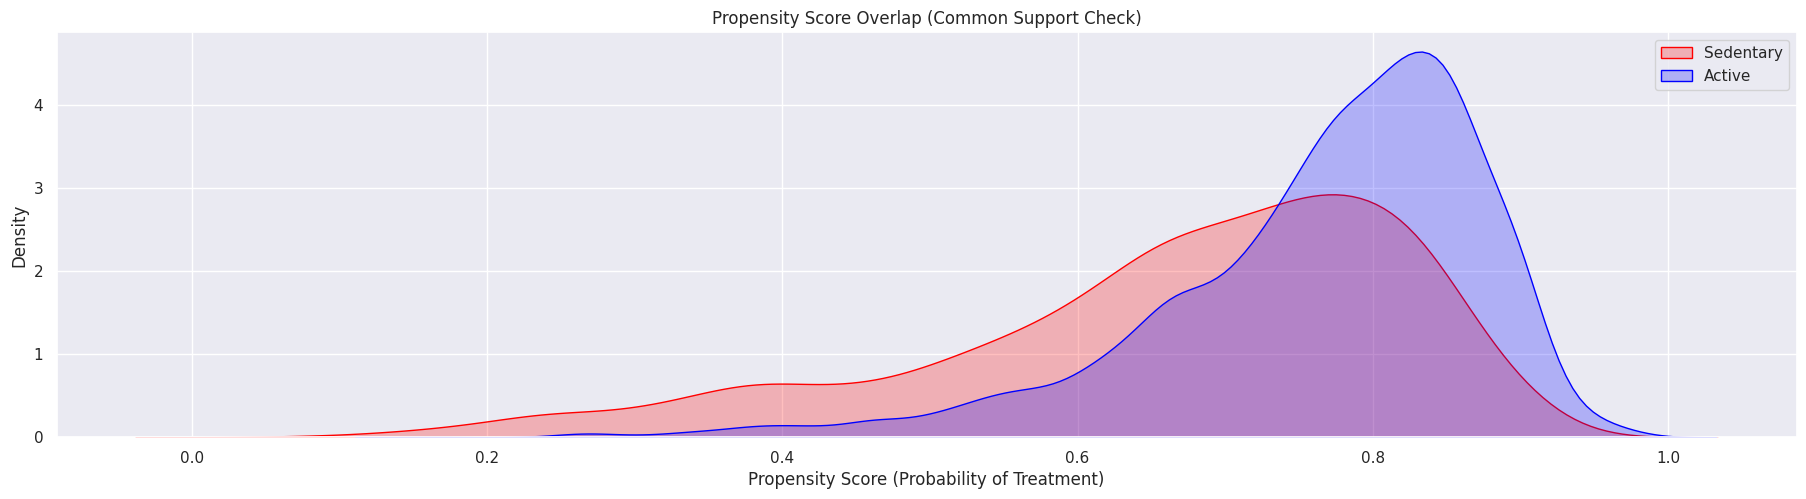

--- Diagnostic Interpretation ---
Good Overlap: The red and blue distributions share the same x-axis range
Bad Overlap: One group is clustered at 0 and the other at 1 (Positivity Violation)


In [7]:
# Check if there is "Common Support" between the treated and control groups.
navigator.check_overlap(X_demo, T_demo)

### `fit_estimate(X, T, Y)`

**Purpose**: Trains the meta-learner and estimates CATE (Conditional Average
Treatment Effect).

- **Inputs**: Covariates `X`, Treatment `T`, Outcome `Y`
- **Output**: `numpy.array` of CATE values - one per observation
- **Design choice**: XGBoost is used as the base learner because it handles
  non-linearities in the response surface effectively, which is crucial for
  the X-Learner

In [8]:
# Estimate effects.
cate_estimates = navigator.fit_estimate(X_demo, T_demo, Y_demo)
print(f"\nAverage Treatment Effect (ATE): {cate_estimates.mean():.4f}")

Mapping labels: 0.0 -> Sedentary, 1.0 -> Active
Training X-Learner with XGBoost base models
Generating propensity score
predict_proba not available, using predict instead
Error metrics for group Active
    RMSE   (Control):     0.3144
    RMSE (Treatment):     0.2831
   sMAPE   (Control):     1.7021
   sMAPE (Treatment):     1.8694
    Gini   (Control):     0.8328
    Gini (Treatment):     0.7536
Done. Estimated Average Treatment Effect (ATE): -0.0152

Average Treatment Effect (ATE): -0.0152


### `get_cate_df(df_original)`

**Purpose**: Helper to merge the estimated effects back into the original
dataframe.

- **Inputs**: Original dataframe
- **Output**: Dataframe with a new `cate` column

### `plot_heterogeneity(df_with_cate, col, bins=5)`

**Purpose**: Visualises how the treatment effect varies across a specific
feature.

- **Inputs**: Dataframe with CATE, column name, optional bins
- **Output**: A bar chart showing CATE by group with confidence intervals

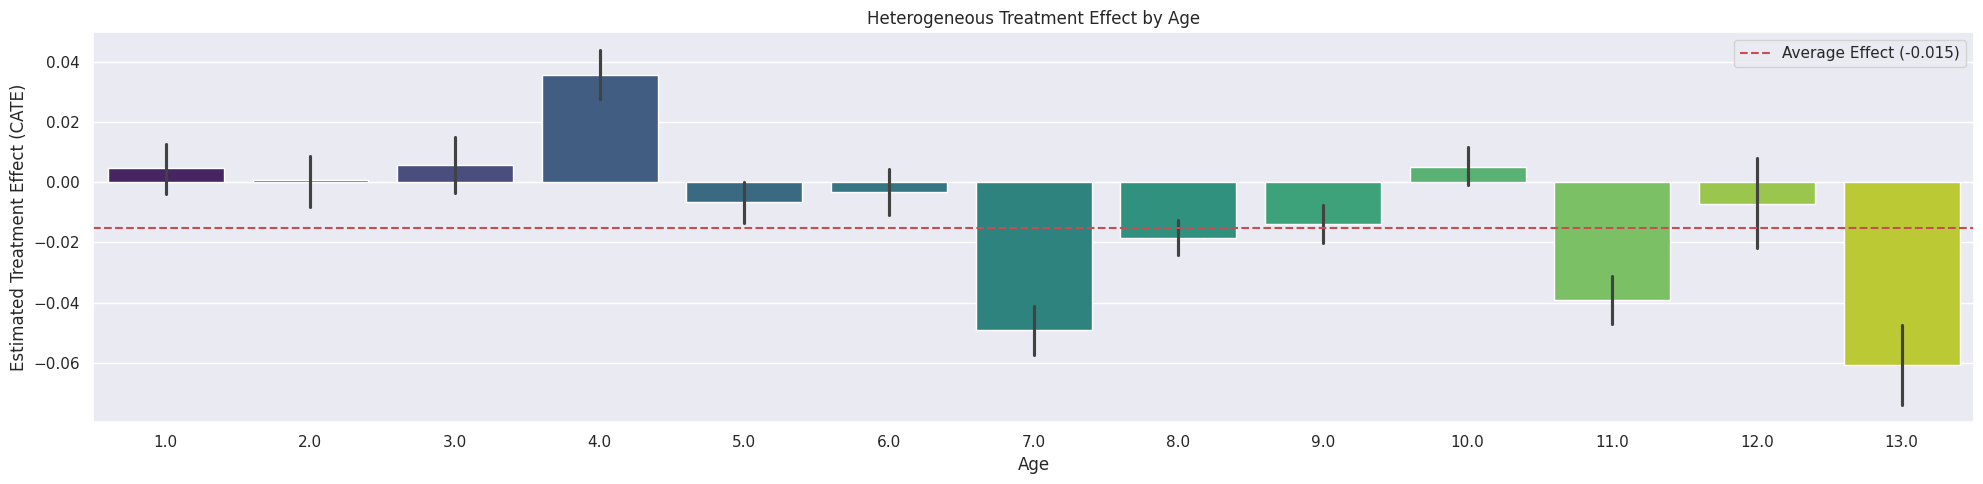

In [9]:
# Visualize results.
df_results = navigator.get_cate_df(X_demo)
navigator.plot_heterogeneity(df_results, col="Age")

### `run_placebo_test(X, T, Y, n_simulations=10)`

**Purpose**: Robustness check (Refutation).

- **Logic**: Randomly shuffles the treatment array to break any true causal
  link, then re-trains the model
- **Success criteria**: The "Placebo ATE" should cluster around 0; the
  "Actual ATE" should be far outside this distribution
- **Interpretation**: If the actual effect falls *inside* the placebo
  distribution, the result is statistically indistinguishable from noise

Running Placebo Test (3 permutations)
Generating propensity score
predict_proba not available, using predict instead
Error metrics for group Active
    RMSE   (Control):     0.2732
    RMSE (Treatment):     0.3013
   sMAPE   (Control):     1.7878
   sMAPE (Treatment):     1.8411
    Gini   (Control):     0.8686
    Gini (Treatment):     0.7417
   Sim 1/3: Placebo ATE = -0.01002
Generating propensity score
predict_proba not available, using predict instead
Error metrics for group Active
    RMSE   (Control):     0.2691
    RMSE (Treatment):     0.3031
   sMAPE   (Control):     1.8172
   sMAPE (Treatment):     1.8316
    Gini   (Control):     0.8492
    Gini (Treatment):     0.7525
   Sim 2/3: Placebo ATE = -0.00045
Generating propensity score
predict_proba not available, using predict instead
Error metrics for group Active
    RMSE   (Control):     0.2690
    RMSE (Treatment):     0.3021
   sMAPE   (Control):     1.8181
   sMAPE (Treatment):     1.8301
    Gini   (Control):     0.8659
 

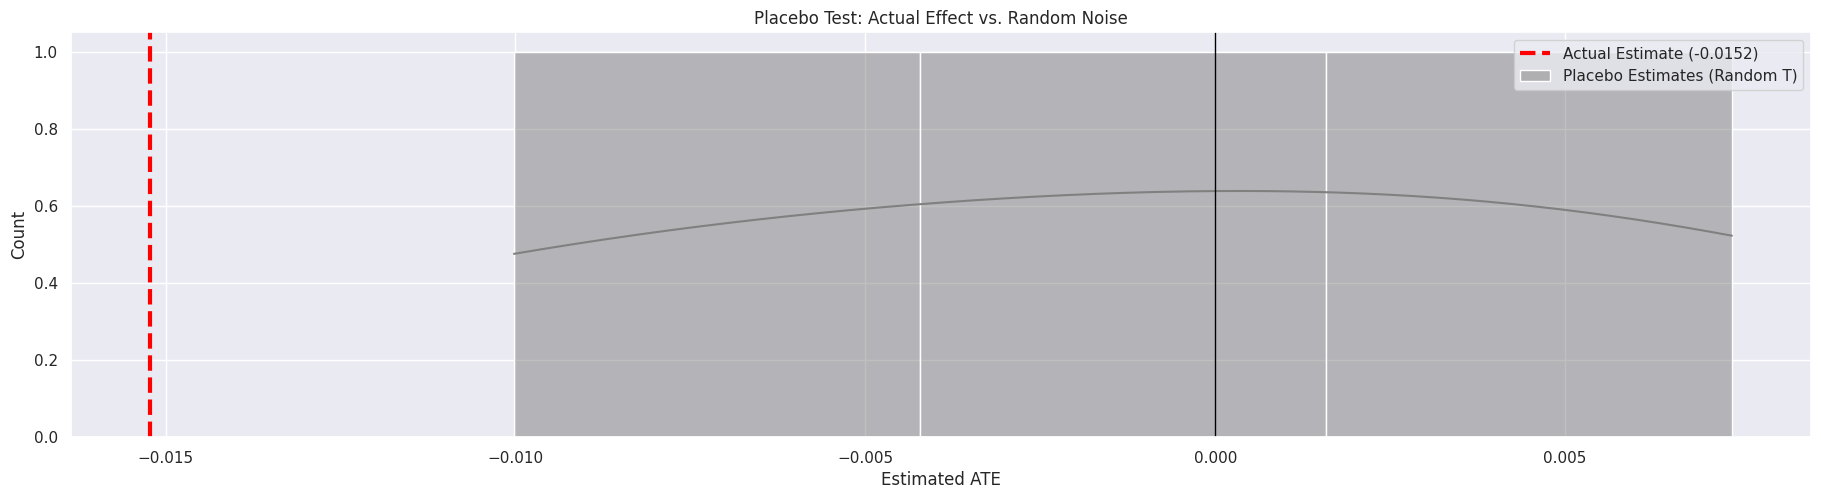

In [10]:
# Robustness check: shuffle T to see if the model finds an effect where none
# exists.
navigator.run_placebo_test(X_demo, T_demo, Y_demo, n_simulations=3)

### `run_sensitivity_analysis(X, T, Y)`

**Purpose**: Quantifies the stability of the causal estimate.

- **Logic**: Iteratively removes one covariate at a time and re-calculates
  the Average Treatment Effect (ATE)
- **Output**: A horizontal bar chart showing the ATE for each scenario
  compared to the baseline
- **Interpretation**:
  - **Stable** - bars cluster near the baseline (red line)
  - **Sensitive** - a bar shifts significantly or crosses zero, indicating
    that specific variable drives the result

Running Sensitivity Analysis (Covariate Removal)
   Baseline ATE: -0.01522
   ... testing robustness without 'HighBP'
Generating propensity score
predict_proba not available, using predict instead
Error metrics for group Active
    RMSE   (Control):     0.3189
    RMSE (Treatment):     0.2862
   sMAPE   (Control):     1.7075
   sMAPE (Treatment):     1.8727
    Gini   (Control):     0.8155
    Gini (Treatment):     0.7379
   ... testing robustness without 'HighChol'
Generating propensity score
predict_proba not available, using predict instead
Error metrics for group Active
    RMSE   (Control):     0.3215
    RMSE (Treatment):     0.2850
   sMAPE   (Control):     1.7096
   sMAPE (Treatment):     1.8709
    Gini   (Control):     0.8111
    Gini (Treatment):     0.7492
   ... testing robustness without 'Age'
Generating propensity score
predict_proba not available, using predict instead
Error metrics for group Active
    RMSE   (Control):     0.3331
    RMSE (Treatment):     0.2931
   sM

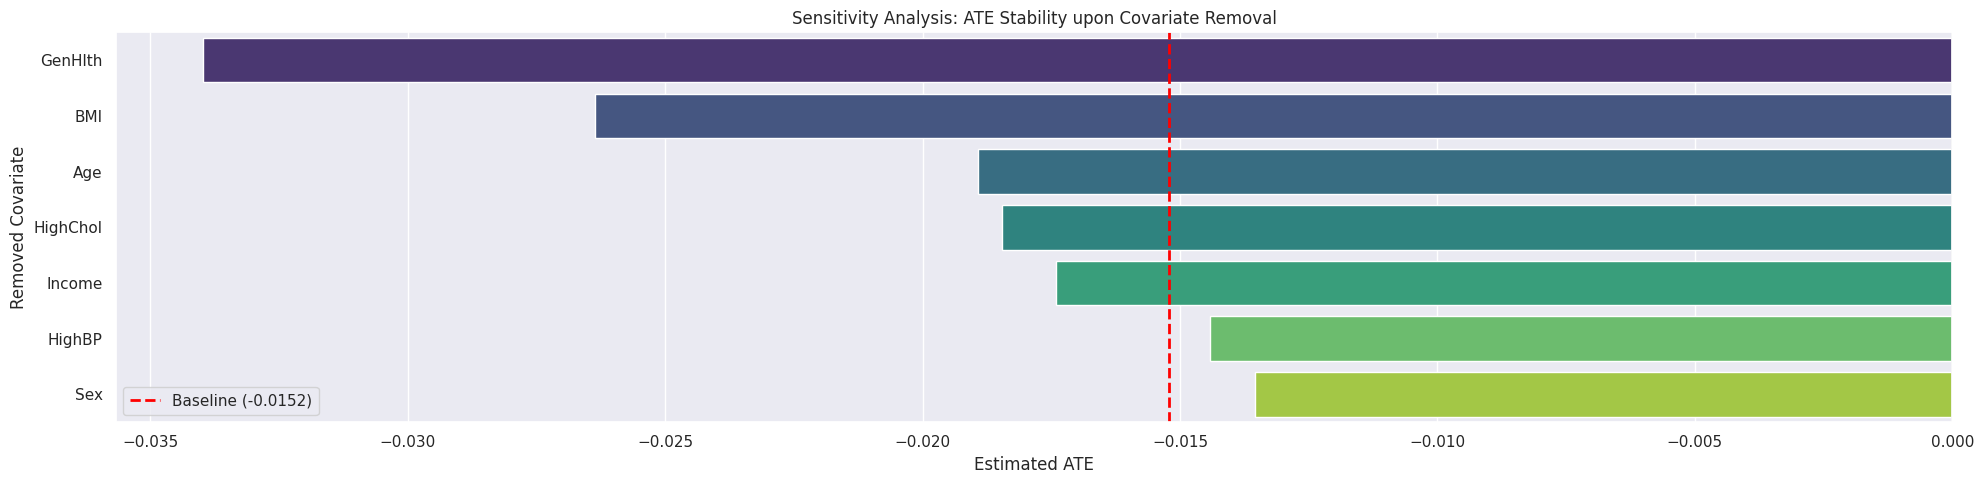

Interpretation: Variables causing large shifts from the red line are critical confounders


In [11]:
# Sensitivity analysis: check how stable the result is when removing one
# covariate at a time.
navigator.run_sensitivity_analysis(X_demo, T_demo, Y_demo)

### `compare_estimators(X, T, Y)`

**Purpose**: Advanced model selection ("Horse Race").

- **Methodology**: Splits data into Train (70%) and Test (30%); trains S, T,
  X, R, and DR learners on the training set
- **Metric**: Generates a **Cumulative Gain Chart (Uplift Curve)** on the
  test set
- **Why this metric**: Since ground-truth CATE is impossible to observe, RMSE
  cannot be used. The Gain Chart measures how well a model sorts individuals
  from "High Responder" to "Low Responder"
- **Outputs**:
  - **Uplift Curve Plot** - visual comparison of model performance
  - **Qini/AUUC Score Table** - numerical ranking of models (Area Under
    Uplift Curve)

Starting Estimator Tournament
Training S-Learner
Training T-Learner
Training X-Learner
Generating propensity score
predict_proba not available, using predict instead
Generating propensity score
Training R-Learner
Generating propensity score
predict_proba not available, using predict instead
generating out-of-fold CV outcome estimates
training the treatment effect model for 1.0 with R-loss
Training DR-Learner
Generating propensity score
predict_proba not available, using predict instead
Generate outcome regressions
Fit pseudo outcomes from the DR formula
Generating propensity score
predict_proba not available, using predict instead
Generate outcome regressions
Fit pseudo outcomes from the DR formula
Generating propensity score
predict_proba not available, using predict instead
Generate outcome regressions
Fit pseudo outcomes from the DR formula
Generating Uplift Curves (Metrics on Test Set)
--- Qini / AUUC Scores (Higher is Better) ---

T-Learner    -0.480162
DR-Learner   -0.486017
X-Le

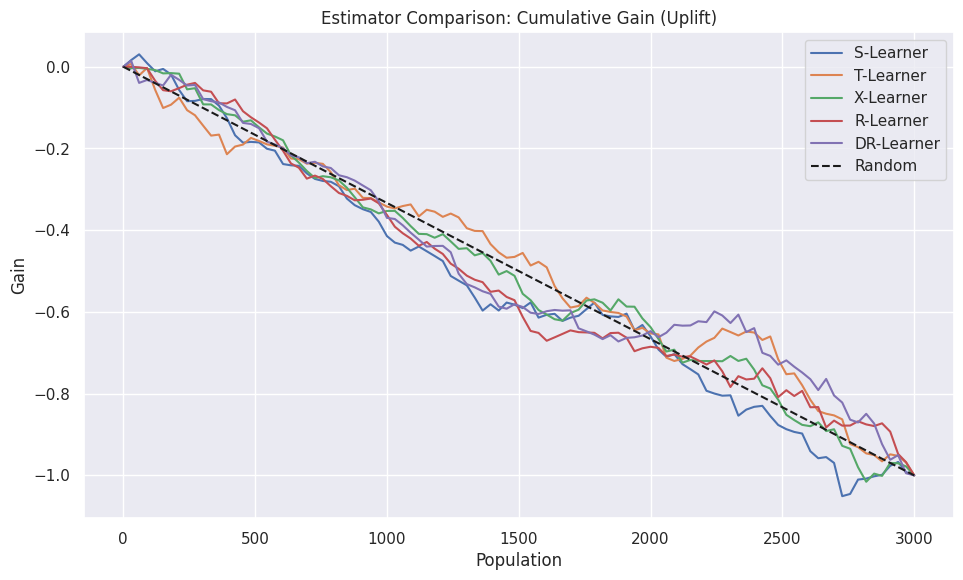

Interpretation: The line that stays highest on the Y-axis sorts patients best


In [12]:
# Estimator comparison ("Horse Race"): compare X-Learner against S, T, R, and
# DR Learners using Uplift Curves.
navigator.compare_estimators(X_demo, T_demo, Y_demo)